# Time Series Visualization

Line plots for time series data with date formatting support.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Generate test data
np.random.seed(42)
dates = pd.date_range("2022-01-01", "2023-12-31", freq='D')
n = len(dates)

# Simulated missing rates
def gen_missing(n, base=50, amp=30):
    seasonal = amp * np.sin(2 * np.pi * np.arange(n) / 365)
    trend = np.linspace(0, 10, n)
    noise = np.random.normal(0, 5, n)
    return np.clip(base + seasonal + trend + noise, 0, 100)

cha = gen_missing(n, 60, 25)
par = gen_missing(n, 40, 20)
sst = gen_missing(n, 30, 15)

## Single Time Series


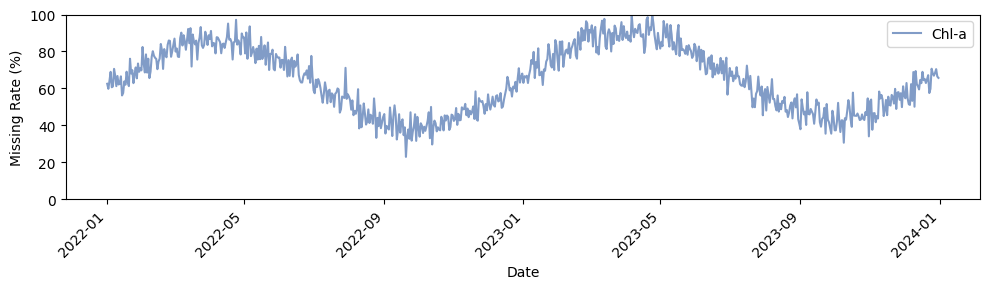

In [2]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dates, cha, color='#4C72B0', linewidth=1.5, alpha=0.7, label='Chl-a')
ax.set_xlabel("Date")
ax.set_ylabel("Missing Rate (%)")
ax.set_ylim(0, 100)
ax.legend(frameon=True)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Multi-panel Time Series Grid


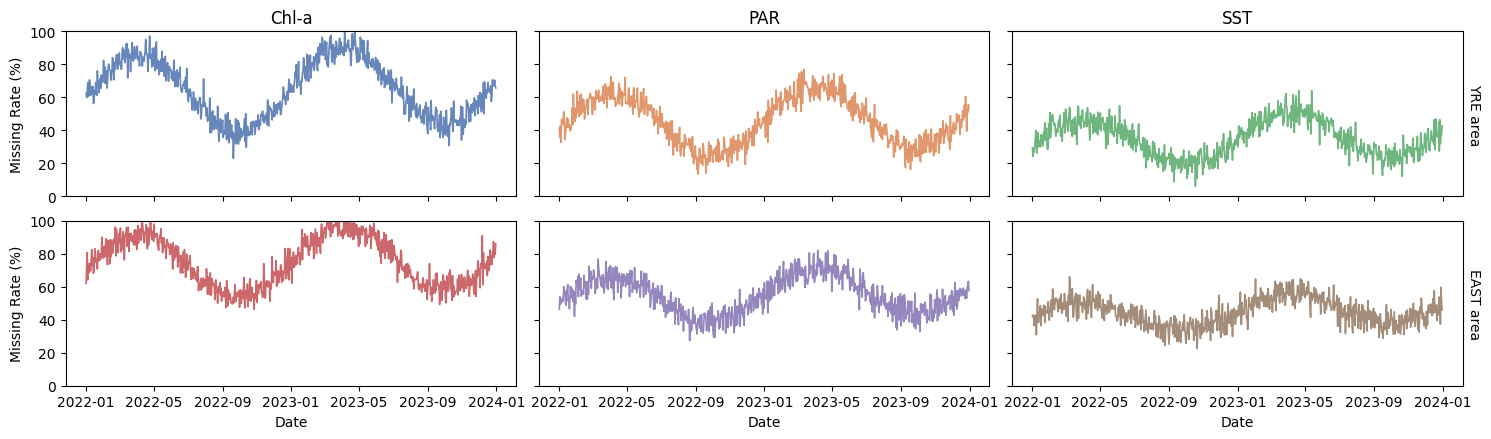

In [3]:
# Prepare data grid (2 regions × 3 variables)
data_grid = [
    [cha, par, sst],
    [gen_missing(n, 70, 20), gen_missing(n, 50, 15), gen_missing(n, 40, 10)]
]

row_labels = ["YRE area", "EAST area"]
col_labels = ["Chl-a", "PAR", "SST"]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

fig, axes = plt.subplots(2, 3, figsize=(15, 4.5), sharex=True, sharey=True)

for i in range(2):
    for j in range(3):
        ax = axes[i, j]
        ax.plot(dates, data_grid[i][j], color=colors[i*3+j], linewidth=1.2, alpha=0.85)
        
        if i == 1:
            ax.set_xlabel("Date")
        if j == 0:
            ax.set_ylabel("Missing Rate (%)")
        if i == 0:
            ax.set_title(col_labels[j])
        if j == 2:
            ax.text(1.01, 0.5, row_labels[i], rotation=270, va='center', transform=ax.transAxes)
        
        ax.set_ylim(0, 100)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.15)
plt.show()

## Missing Rate Calculation


Data shape: (100, 576)
Missing rate range: [16.5, 24.7]%


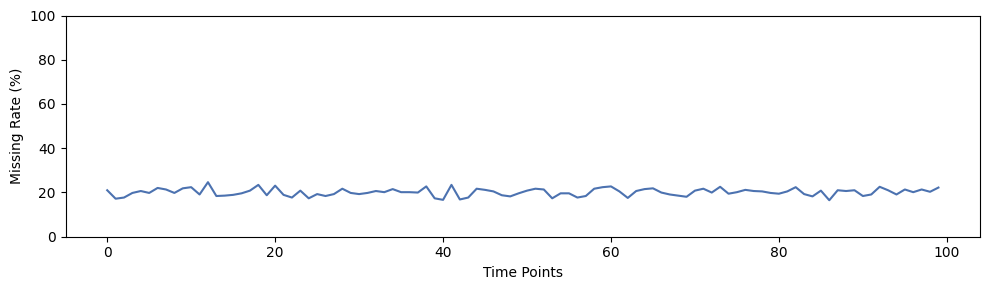

In [4]:
def calc_missing_rate(data, missing_val=0.0):
    """Calculate missing rate per time point"""
    return (data == missing_val).sum(axis=1) / data.shape[1] * 100

# Example usage
np.random.seed(123)
sim_data = np.random.randn(100, 576) * 10 + 50
missing_mask = np.random.rand(100, 576) < 0.2
sim_data[missing_mask] = 0

missing_rates = calc_missing_rate(sim_data)
print(f"Data shape: {sim_data.shape}")
print(f"Missing rate range: [{missing_rates.min():.1f}, {missing_rates.max():.1f}]%")

plt.figure(figsize=(10, 3))
plt.plot(missing_rates, color='#4C72B0', linewidth=1.5)
plt.xlabel("Time Points")
plt.ylabel("Missing Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()